<a href="https://colab.research.google.com/github/xeeteex/local-models-ocr/blob/main/quantization_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**int8 Quantization**

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# simulating model weights
x = np.linspace(-1.0, 1.0, 100)
x[:10]

array([-1.        , -0.97979798, -0.95959596, -0.93939394, -0.91919192,
       -0.8989899 , -0.87878788, -0.85858586, -0.83838384, -0.81818182])

In [ ]:
# quantization parameters
max_x = 1.0
min_x = -1.0
qmin = -128
qmax = 127

# scale for symmetric quantization
scale = (max_x-min_x)/(qmax-qmin)
scale

0.00784313725490196

In [ ]:
zero_point = 0

# quantization int8 -> float
q = np.round((x - zero_point)/scale).astype(int)

q = np.clip(q, qmin, qmax)
q[:10]

array([-128, -125, -122, -120, -117, -115, -112, -109, -107, -104])

In [ ]:
# dequantization int8-> float
x_hat = scale * (q-zero_point)
x_hat[:10]

array([-1.00392157, -0.98039216, -0.95686275, -0.94117647, -0.91764706,
       -0.90196078, -0.87843137, -0.85490196, -0.83921569, -0.81568627])

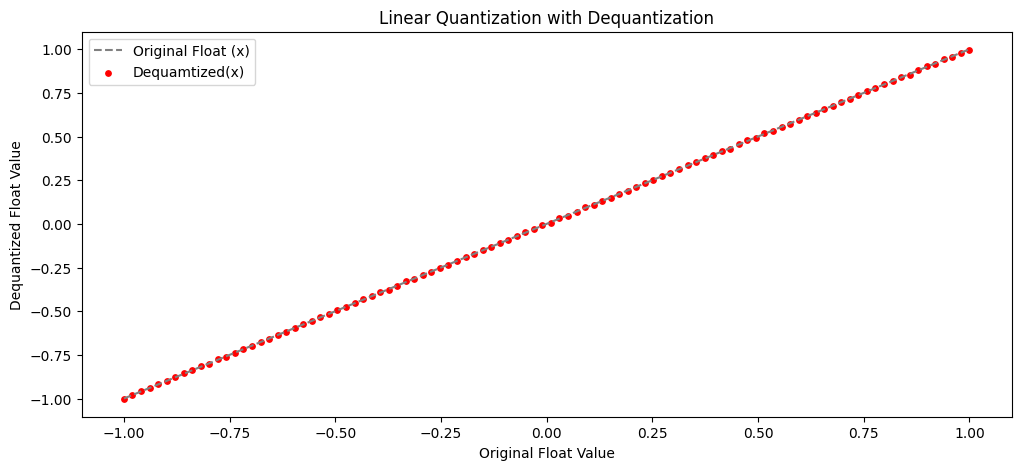

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(x, x, label = 'Original Float (x)', linestyle = '--', color = "gray" )
plt.scatter(x, x_hat, label = 'Dequamtized(x)', color = 'red', s = 15)
plt.title('Linear Quantization with Dequantization')
plt.xlabel('Original Float Value')
plt.ylabel('Dequantized Float Value')
plt.legend()
plt.show()